In [1]:
#############################################
##### this is a testscript to process Katha's video to prepare for SLEAP
##### it is based on the axolotl_tracking_batch_v1.3.ipynb for Deniz's animal tracking
#############################################

In [2]:
import numpy as np
import pandas as pd
import tracktor as tr
import cv2
import sys
import time
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import os
from pathlib import Path
import math
from skimage.io import imread
from skimage import filters
import gc

In [3]:
## try to speed up the cv2 calling 
print(cv2.useOptimized())
cv2.setUseOptimized(True)
print(os.cpu_count())
cv2.setNumThreads(1)

True
10


In [4]:
## global function to find alternative circle with fllodfill, findcontour and find minimal circle 
def circle_ostu_floodfill_contour_mincircle(frame, circle_center):
    
    frame_ring = frame.copy()
    
    circle_x = circle_center[0]
    circle_y = circle_center[1]
    
    mask_ring = np.zeros(frame_ring.shape)
    mask_ring = cv2.circle(mask_ring, (circle_x, circle_y), 150 , (255,255,255), -1)
    
    frame_ring[mask_ring ==  0] = 0
    
    ## gaussian blur
    gray_ring = cv2.cvtColor(frame_ring, cv2.COLOR_BGR2GRAY)
    blur_ring = cv2.GaussianBlur(gray_ring, (5, 5), 0)
    #plt.imshow(blur_ring,'gray')
    
    _, image_th = cv2.threshold(blur_ring, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU, )
    #print("Obtained threshold: ", otsu_threshold)
    
    # Copy the thresholded image.
    im_floodfill = image_th.copy()
    # Mask used to flood filling.
    # Notice the size needs to be 2 pixels than the image.
    h, w = image_th.shape[:2]
    mask_floodfill = np.zeros((h+2, w+2), np.uint8)
    
    # Floodfill from point (0, 0)
    cv2.floodFill(im_floodfill, mask_floodfill, (0,0), 255);
    #cv2.floodFill(im_floodfill, mask_floodfill, (250,250), 255);
    #plt.imshow(im_floodfill,'gray')
    
    cv2.floodFill(im_floodfill, mask_floodfill, (299, 299), 255);
    cv2.floodFill(im_floodfill, mask_floodfill, (0, 299), 255);
    cv2.floodFill(im_floodfill, mask_floodfill, (299, 0), 255);
    #plt.imshow(im_floodfill,'gray')
    
    # Invert floodfilled image
    im_floodfill_inv = cv2.bitwise_not(im_floodfill)
    #plt.imshow(im_floodfill_inv,'gray')
    
    contours, hierarchy = cv2.findContours(im_floodfill_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    #disk = np.zeros_like(im_floodfill_inv)

    if contours:
        biggest_contour = max(contours, key=cv2.contourArea)
    
        (x, y), radius = cv2.minEnclosingCircle(biggest_contour)
        
        #center = (int(x), int(y))
        #radius = int(radius)
        
        #print("Center:", center)
        #print("Radius:", radius)
        circle_new = [int(x), int(y), int(radius)]
        # Draw circle for visualization
        #output = cv2.cvtColor(im_floodfill_inv, cv2.COLOR_GRAY2BGR)
        #cv2.circle(output, center, radius, (0, 255, 0), 2)
        #cv2.circle(output, center, 2, (0, 0, 255), 3)
        
        #cv2.imshow("Minimal enclosing circle", output)
        #cv2.waitKey(0)
        
        #cv2.drawContours(disk, [biggest_contour], -1, 255, thickness=cv2.FILLED)
        return circle_new
        
    else:
        
        return None


## Global parameters
This cell (below) enlists user-defined parameters

In [5]:
# colours is a vector of BGR values which are used to identify individuals in the video
# since we only have one individual, the program will only use the first element from this array i.e. (0,0,255) - red
# number of elements in colours should be greater than n_inds (THIS IS NECESSARY FOR VISUALISATION ONLY)
n_inds = 1
#colours = [(255,0,0),(0,255,255),(255,0,255),(255,255,255),(255,255,0),(255,0,0),(0,255,0),(0,0,0)]
colours = [(0,0,255),(0,255,255),(255,0,255), (255,255,0),(255,0,0),(0,255,0)]

# this is the block_size and offset used for adaptive thresholding (block_size should always be odd)
# these values are critical for tracking performance
#block_size = 51
#offset = 20

# the scaling parameter can be used to speed up tracking if video resolution is too high (use value 0-1)
# not use fixed scaling, rather calculate the scaling_img to reduce the all images to 300*300
#scaling = 1.0 

# mot determines whether the tracker is being used in noisy conditions to track a single object or for multi-object
# using this will enable k-means clustering to force n_inds number of animals
mot = False

## parameters added for axolotl images
nb_skippedFrame = 700 # nb of frames to skip to make sure axolotl is there

## parameters for the circle searching
minRadius_init = 120
maxRadius_init = 140

## main parameters to ajust for videos/animals
circles_dp = 1 # 1, 1.2, 1.5 or 2.0
circle_dist = 4 # 2, 4, 50  
circle_offset = 4 # 2, 4, 6, 8
circle_offset_alt = 4

#threshold_quantile = 0.997 #use the adpative thresholding searach, this parameter used when the animal with high intensity and circle border is dim
threshold_quantile = 0.995 # thise parameter is used when the circle border has high intensity or animal intensity is dim


# minimum area and maximum area occupied by the animal in number of pixels
# this parameter is used to get rid of other objects in view that might be hard to threshold out but are differently sized
min_area = 100 
max_area = 800
min_circularity = 0.1 ## minimum circularity of object for detected animal

#### 
display_outFrame = True
test_processing = True

In [7]:
# name of source video and paths
input_vidpath = '/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/Katha_video_sleap_test/' # path to all video folders
output_dir = '/Users/jingkui.wang/workspace/imp/image_analysis_test/results/videos_sleap_test/'

codec = 'DIVX' # try other codecs if the default doesn't work ('DIVX', 'avc1', 'XVID') note: this list is non-exhaustive

if test_processing:
    output_dir = output_dir + 'test/'

if not os.path.exists(output_dir):
    os.mkdir(output_dir)
    
print(output_dir)

/Users/jingkui.wang/workspace/imp/image_analysis_test/results/videos_sleap_test/test/


In [8]:
directory = Path(input_vidpath)

folder_names = [p.name for p in directory.iterdir() if p.is_dir()]

print("nb of videos to process: " + str(len(folder_names)) + ":")
#print('-----')
print(folder_names)

nb of videos to process: 1:
['wildtype_A1']


In [8]:
## test only specific video
#folder_names = folder_names[0]

#print(folder_names)
#if isinstance(folder_names, str):
#    folder_names = [folder_names]
#for folder in folder_names:
#    print(folder)
print(folder_names)
print(len(folder_names))

['wildtype_A1']
1


In [9]:
###############################################
##### run all videos in the specified folders
###############################################

In [ ]:
if isinstance(folder_names, str):
    folder_names = [folder_names]
    
for folder in folder_names:
    
    ## Start time
    start = time.time()
    
    print(folder)
    
    video = folder
    output_vidpath = output_dir + video + '.mp4'
    output_filepath = output_dir + video + '.csv'
    output_figpath = output_dir + video + '.pdf'
    output_error = output_dir + video + '_error.csv'
    output_circle = output_dir + video + '_circle.csv'
    
    video_path = Path(input_vidpath + folder + '/')
    
    first_file = next(p.name for p in video_path.iterdir() if p.is_file() and p.name.endswith(".tiff"))
    
    #first_file = next(p.name for p in video_path.iterdir() if p.is_file())
    #files = [p for p in video_path.iterdir() if p.is_file()]
    #first_file = files[0].name
    file_name = Path(first_file).stem
    #print(file_name)
    file_split = file_name.split("_")
    f_newname = "_".join(file_split[:-1])
    
    print(f_newname)
    #'1_D1_test/Basler_acA2040-120um__24899445__20260407_140424600_%04d.tiff'
    
    ##########
    # check the image size of first file to determine the scaling parameter for x and y
    # scale all images to 300*300 pixels
    ##########
    img = imread(input_vidpath + '/' + folder + '/' + f_newname + '_0000.tiff')
    scaling_img_0 = 300/img.shape[0]
    scaling_img_1 = 300/img.shape[1]
    
    img_shape = img.shape
    
    print('image size : ' + str(img.shape[0]) + ', ' + str(img.shape[1]))
    print('scaling factor : ' + str(scaling_img_0) + ',' + str(scaling_img_1))
    
    del img
    
    ###################################################
    ### loop over videos
    ###################################################
    ## Open video
    cap = cv2.VideoCapture(input_vidpath + '/' + folder + '/' + f_newname + '_%04d.tiff')
    
    if cap.isOpened() == False:
        sys.exit('Video file cannot be read! Please check input_vidpath to ensure it is correctly pointing to the video file')

    ## Video writer class to output video with contour and centroid of tracked object(s)
    # make sure the frame size matches size of array 'final'
    fourcc = cv2.VideoWriter_fourcc(*codec)
    output_framesize = (int(cap.read()[1].shape[1]*scaling_img_1), int(cap.read()[1].shape[0]*scaling_img_0))
    print('output_framesize -- ' + str(output_framesize[0]) + ', ' +  str(output_framesize[1]))
    
    out = cv2.VideoWriter(filename = output_vidpath, fourcc = fourcc, fps = 30.0, frameSize = output_framesize, isColor = True)

    ## Individual location(s) measured in the last and current step
    meas_last = list(np.zeros((n_inds,2)))
    meas_now = list(np.zeros((n_inds,2)))
    
    last = 0
    df = []
    err = []
    
    ## first frame to detect the coordinate and radius of circles
    #cap.set(1,1)
    ## strat the tracing from the frame 500 to skip those without axolotl
    cap.set(1, nb_skippedFrame)
    
    ret, frame = cap.read()
    
    frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)
    
    print(frame.shape)
    
    ###################################################
    ### circle searching
    ### add adapt circle searching with maxRadius
    ###################################################
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur_frame = cv2.medianBlur(gray_frame, 5)
    
    #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = maxRadius_init)
    circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = circles_dp, minDist = circle_dist, minRadius = minRadius_init, maxRadius = maxRadius_init) ## add param1 and param2; reduce the distance 
    
    if circles is None:
        #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = (maxRadius_init + 5))
        circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = circles_dp, minDist = circle_dist, minRadius = minRadius_init, maxRadius = (maxRadius_init + 5)) ## add param1 and param2; reduce the distance 
        
        if circles is None:
            #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = (maxRadius_init + 10))
            circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = circles_dp, minDist = circle_dist, minRadius = minRadius_init, maxRadius = (maxRadius_init + 10)) 
            
    
    if circles is not None:
        #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 10, minRadius = 120, maxRadius = 150)
        #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = 140)
        
        circles = np.round(circles[0, :]).astype("int")
        
        # Sort by radius, smallest first
        circles = sorted(circles, key=lambda c: c[2])

        # Smallest circle with general parameteres
        circle_run = circles[0]
        
        circle_x = circle_run[0]
        circle_y = circle_run[1] 
        circle_radius = circle_run[2] - circle_offset
        
        #circles = np.uint8(np.around(circles))
        #print(circle_run)
        #if len(circles) == 1:
        #    circle_run = circles[0,:][0]
        #else:
        #    print(' > 1 circles found but select the first one ')
        #    circle_run = circles[0,:][0]
        #circle_x = circle_run[0]
        
        ## general parameters
        #circle_y = circle_run[1]
        #circle_radius = 130
        #circle_radius = circle_run[2] - 2
        
        # ajust parameter for A39_1wpt_5_L2
        #circle_y = circle_run[1] + 3
        #circle_radius = circle_run[2] - 5
        
        circle_position = [circle_x, circle_y, circle_radius]
        
        print(circle_position)
        
        ### add alternative circle searching function
        try:
            #circle_new = circle_ostu_floodfill_contour_mincircle(frame, [circle_x, circle_y])
            #circle_new = circle_ostu_floodfill_contour_mincircle(frame, [150, 150])
            #print(circle_new)
            
            #circle_new2 = circle_ostu_floodfill_contour_mincircle(frame, [150, 150])
            #print(circle_new2)
            
            circle_new = circle_ostu_floodfill_contour_mincircle(frame, [circle_x, circle_y])
            #circle_new = circle_ostu_floodfill_contour_mincircle(frame, [150, 150])
            print(circle_new)
            
            
            if circle_new is not None and circle_new[2] >= 110:
                circle_new[2] = circle_new[2] - circle_offset_alt
                circle_position = circle_new
                
            else:
                print('search for alternative circle for 2nd time')
                #circle_new2 = circle_ostu_floodfill_contour_mincircle(frame, [circle_x, circle_y])
                circle_new2 = circle_ostu_floodfill_contour_mincircle(frame, [150, 150])
                print(circle_new2)
                
                if circle_new2 is not None and circle_new2[2] >= 110:
                    circle_new2[2] = circle_new2[2] - circle_offset_alt
                    circle_position = circle_new2
                else:
                    print('no alternative circle found')
                    
        except:
            print("error in the alternative circle searching")
            
            
        print(circle_position)
        
        circle_coord = circle_position.extend([img_shape[0], img_shape[1], scaling_img_0, scaling_img_1])
        circle_coord = pd.DataFrame(np.matrix(circle_position), columns = ['x','y','radius', 'originalImage_x', 'originalImage_y', 'scaling_x', 'scaling_y'])
        
        circle_coord.to_csv(output_circle, sep=',')
        
    else:
        print(' no circles found !!! ')
        #break
        continue
    
    del circle_x, circle_y, circle_radius, circle_new, circles, circle_run, blur_frame, gray_frame, circle_coord
    gc.collect()
    
    
    ###################################################
    ### searching the animal contour within the circle identified above
    ### frame by frame
    ### save the processed videos and trajectory
    ###################################################
    while(True):
        # Capture frame-by-frame
        ret, frame = cap.read()
        
        this = cap.get(1)
    
        if ret == True:
            frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)
        
            # Apply mask to the area of interest
            mask = np.zeros(frame.shape)
            #mask = cv2.circle(mask, (308, 235), 215, (255,255,255), -1)
            #mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
            mask = cv2.circle(mask, (circle_position[0], circle_position[1]), circle_position[2], (255,255,255), -1)
            
            #frame[mask ==  0] = np.median(frame[mask >  0])
            frame[mask ==  0] = 0
        
            blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            #blur = cv2.medianBlur(blur, 5)
            blur = cv2.GaussianBlur(blur, (5, 5), 0)
            
            threshold_value = np.quantile(blur.ravel(), threshold_quantile)
            
            _, thresh = cv2.threshold(blur, threshold_value, 255, cv2.THRESH_BINARY)
            #thresh = tr.colour_to_thresh(frame, block_size, offset)
            #thresh = binary
            final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area, min_circularity = 0.1)
            
            try:
                row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
                final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)
            except:
                #print(this,  "frame Error")
                err.append([f_newname, this])
                continue
            
            # Create output dataframe
            for i in range(n_inds):
                df.append([this, meas_now[i][0], meas_now[i][1]])
        
            # Display the resulting frame
            out.write(final)
            
            if this % 100 == 0:
                cv2.imshow('frame', final)
                if cv2.waitKey(1) == 27:
                    break
            
        if last == this:
            break
    
        last = this
    
    ## Write positions to file
    if len(df) > 0:
        df = pd.DataFrame(np.matrix(df), columns = ['frame','pos_x','pos_y'])
        df.to_csv(output_filepath, sep=',')

    if len(err) > 0:
        err = pd.DataFrame(np.matrix(err), columns = ['video','frame'])
        err.to_csv(output_error, sep=',')
    
    ## When everything done, release the capture
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)
    
    del cap
    gc.collect()
    
    ####################################
    # Plot tracks
    # The code below allows you to see individual tracks. By counting the number of jumps in the tracks, one can identify number of false detections.
    ####################################
    #if Path(output_filepath).is_file():
    if os.path.isfile(output_filepath):
        df = pd.read_csv(output_filepath)
        
        plt.figure(figsize=(8, 8))
        plt.scatter(df['pos_x'], df['pos_y'], c=df['frame'])
        plt.xlabel('pos_x')
        plt.ylabel('pos_y')
        plt.savefig(output_figpath, format = 'pdf', bbox_inches="tight")
        plt.close()
        
    else:
        print(' no frame processed !!! ')
        
    ## End time and duration
    end = time.time()
    duration = np.around((end - start)/60)
    
    print("--- %s minutes ---" %duration)
    

A58_1wpt_1_D1
Basler_acA2040-120um__24899445__20260408_133530467
image size : 300, 300
scaling factor : 1.0,1.0
output_framesize -- 300, 300


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


(300, 300, 3)
[np.int64(152), np.int64(150), np.int64(124)]
[154, 147, 132]
[154, 147, 128]
--- 31.0 minutes ---
A58_1wpt_2_L1
Basler_acA2040-120um__24899445__20260408_141649922
image size : 300, 300
scaling factor : 1.0,1.0
output_framesize -- 300, 300


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


(300, 300, 3)
[np.int64(164), np.int64(148), np.int64(128)]
[163, 149, 134]
[163, 149, 130]
--- 26.0 minutes ---
A58_1wpt_3_L2
Basler_acA2040-120um__24899445__20260408_145630417
image size : 300, 300
scaling factor : 1.0,1.0
output_framesize -- 300, 300


...

(300, 300, 3)
[np.int64(158), np.int64(160), np.int64(122)]
[148, 151, 136]
[148, 151, 132]


[ WARN:0@162955.846] global cap_ffmpeg_impl.hpp:453 _opencv_ffmpeg_interrupt_callback Stream timeout triggered after 54306.626459 ms


--- 34.0 minutes ---
A5_preONT_5_D2
Basler_acA2040-120um__24899445__20260326_161149087
image size : 600, 600
scaling factor : 0.5,0.5
output_framesize -- 300, 300


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


(300, 300, 3)
[np.int64(160), np.int64(160), np.int64(124)]
[107, 289, 7]
search for alternative circle for 2nd time
[148, 151, 136]
[148, 151, 132]


In [ ]:
###########################################################
###########################################################
## debug specific folder or file
###########################################################
###########################################################

In [116]:
# name of source video and paths
input_vidpath = '/Volumes/groups/tanaka/Collaborations/Jingkui-Katharina/behavior/' # path to all video folders
output_dir = '/Users/jingkui.wang/workspace/imp/image_analysis_test/results/videos_sleap_test/'

codec = 'DIVX' # try other codecs if the default doesn't work ('DIVX', 'avc1', 'XVID') note: this list is non-exhaustive

if test_processing:
    output_dir = output_dir + 'test/'

if not os.path.exists(output_dir):
    os.mkdir(output_dir)
    
print(output_dir)

/Users/jingkui.wang/workspace/imp/image_analysis_test/results/videos_sleap_test/test/


In [117]:
from pathlib import Path
directory = Path(input_vidpath)

folder_names = [p.name for p in directory.iterdir() if p.is_dir()]
print(folder_names)
print(len(folder_names))

['SLEAP new', 'wildtype_A1', 'Mutant_A3', 'sleap_test', 'Mutant_A2', 'wildtype_A2', 'wildtype_A3', 'Mutant_A1']
8


In [118]:
## test only specific video
folder_names = [p.name for p in directory.iterdir() if p.is_dir()]

folder_names = folder_names[2]
#print(folder_names)
if isinstance(folder_names, str):
    folder_names = [folder_names]
for folder in folder_names:
    print(folder)

Mutant_A3


In [119]:
#folder = 'A34_1wpt_3_D2'
#folder = 'A15_1wpt_1_D1'
#folder = 'A34_1wpt_2_L1'

In [120]:
print(output_dir)

/Users/jingkui.wang/workspace/imp/image_analysis_test/results/videos_sleap_test/test/


In [121]:
input_vidpath
video = folder
output_vidpath = output_dir + video + '.mp4'

In [122]:
video_path = Path(input_vidpath + folder + '/')

#first_file = next(p.name for p in video_path.iterdir() if p.is_file())
first_file = next(p.name for p in video_path.iterdir() if p.is_file() and p.name.endswith(".tiff"))

print(video_path)
print(first_file)
#files = [p for p in video_path.iterdir() if p.is_file()]
#first_file = files[0].name
file_name = Path(first_file).stem
print(file_name)
file_split = file_name.split("_")
f_newname = "_".join(file_split[:-1])
    
print(f_newname)


/Volumes/groups/tanaka/Collaborations/Jingkui-Katharina/behavior/Mutant_A3
Basler_acA2040-120um__24899445__20260518_133016765_5000.tiff
Basler_acA2040-120um__24899445__20260518_133016765_5000
Basler_acA2040-120um__24899445__20260518_133016765


In [123]:
##########
# check first the shape of image to determine the scaling parameter
##########
img = imread(input_vidpath + '/' + folder + '/' + f_newname + '_0000.tiff')
#scaling_img = 300/img.shape[0]
scaling_img_0 = 1.0
scaling_img_1 = 1.0

cap = cv2.VideoCapture(input_vidpath + '/' + folder + '/' + f_newname + '_%04d.tiff')
    
if cap.isOpened() == False:
    sys.exit('Video file cannot be read! Please check input_vidpath to ensure it is correctly pointing to the video file')


## Individual location(s) measured in the last and current step
meas_last = list(np.zeros((n_inds,2)))
meas_now = list(np.zeros((n_inds,2)))
    
last = 0
df = []
err = []


## Video writer class to output video with contour and centroid of tracked object(s)
# make sure the frame size matches size of array 'final'
fourcc = cv2.VideoWriter_fourcc(*codec)
output_framesize = (int(cap.read()[1].shape[1]*scaling_img_1), int(cap.read()[1].shape[0]*scaling_img_0))
print('output_framesize -- ' + str(output_framesize[0]) + ',' + str(output_framesize[1]))
    
out = cv2.VideoWriter(filename = output_vidpath, fourcc = fourcc, fps = 30.0, frameSize = output_framesize, isColor = True)


print('image size : ' + str(img.shape[0]) + ', ' + str(img.shape[1]))
print('scaling factor : ' + str(scaling_img_0) + ',' + str(scaling_img_1))
print(output_framesize)
    
del img
#print(scaling_img)

output_framesize -- 812,718
image size : 718, 812
scaling factor : 1.0,1.0
(812, 718)


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


In [124]:
cap.set(1, 0)
ret, frame = cap.read()

#frame = cv2.resize(frame, None, fx = scaling_img, fy = scaling_img, interpolation = cv2.INTER_LINEAR)
frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
blur_frame = cv2.medianBlur(gray_frame, 5)
this = cap.get(1)
print(this)

1.0


In [125]:
print(frame.shape)

(718, 812, 3)


In [126]:
np.max(frame)

np.uint8(255)

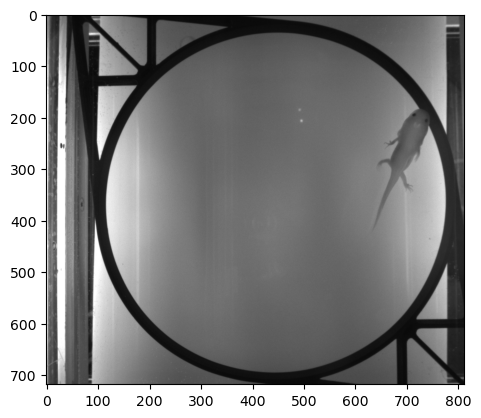

In [127]:
plt.imshow(frame,'gray')

(700, 700, 3)


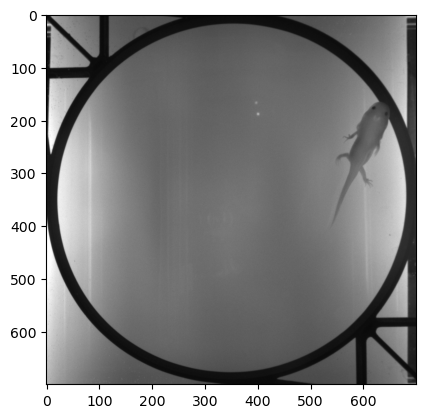

In [128]:
cropped = frame[18:718, 95:795, :]
plt.imshow(cropped,'gray')
print(cropped.shape)

In [129]:
circle_x = 350
circle_y = 350
circle_radius = 350 - 4
print([circle_x, circle_y, circle_radius])

[350, 350, 346]


(700, 700, 3)


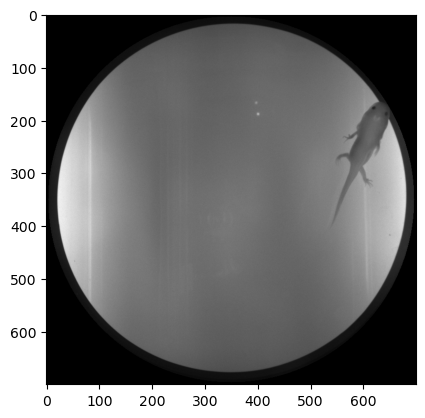

In [130]:
# Apply mask to the area of interest
mask = np.zeros(cropped.shape)
mask = cv2.circle(mask, (circle_x, circle_y), circle_radius, (255,255,255), -1)
cropped[mask ==  0] = 0
plt.imshow(cropped,'gray')
print(cropped.shape)

In [131]:
## try to speed up the cv2 calling 
print(cv2.useOptimized())
cv2.setUseOptimized(True)
print(os.cpu_count())
cv2.setNumThreads(6)

True
10


In [132]:
## Video writer class to output video with contour and centroid of tracked object(s)
# make sure the frame size matches size of array 'final'
fourcc = cv2.VideoWriter_fourcc(*codec)
output_framesize = (700, 700)
print('output_framesize -- ' + str(output_framesize[0]) + ',' + str(output_framesize[1]))
    
out = cv2.VideoWriter(filename = output_vidpath, fourcc = fourcc, fps = 30.0, frameSize = output_framesize, isColor = True)

output_framesize -- 700,700


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


In [133]:
cap.set(1, 0)

True

In [134]:
start = time.time()
while(True):
    # Capture frame-by-frame
    ret, frame = cap.read()
        
    this = cap.get(1)
    
    if ret == True:
        frame = cv2.resize(frame, None, fx = 1.0, fy = 1.0, interpolation = cv2.INTER_LINEAR)
        
        ## crop the image
        cropped = frame[18:718, 95:795, :]
        
        #frame = cv2.resize(frame, None, fx = scaling_img_1, fy = scaling_img_0, interpolation = cv2.INTER_LINEAR)
        #gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        #blur_frame = cv2.medianBlur(gray_frame, 5)
        #this = cap.get(1)
        #print(this)
        
        # Apply mask to the area of interest
        mask = np.zeros(cropped.shape)
        mask = cv2.circle(mask, (circle_x, circle_y), circle_radius, (255,255,255), -1)
            
        cropped[mask ==  0] = 0
        
        #blur = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
        #blur = cv2.medianBlur(blur, 5)
            
        #threshold_value = np.quantile(blur.ravel(), threshold_quantile)
            
        #_, thresh = cv2.threshold(blur, threshold_value, 255, cv2.THRESH_BINARY)
        #thresh = tr.colour_to_thresh(frame, block_size, offset)
        #thresh = binary
        #final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area, min_circularity = 0.1)
        
        # save the resulting frame and display some of them
        out.write(cropped)
        
        cv2.imshow('frame', cropped)
        if cv2.waitKey(1) == 27:
            break
               
    if last == this:
        break
    
    last = this
    
## Write positions to file
if len(df) > 0:
    df = pd.DataFrame(np.matrix(df), columns = ['frame','pos_x','pos_y'])
    df.to_csv(output_filepath, sep=',')

if len(err) > 0:
    err = pd.DataFrame(np.matrix(err), columns = ['video','frame'])
    err.to_csv(output_error, sep=',')
    
## When everything done, release the capture
cap.release()
out.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

        
## End time and duration
end = time.time()
duration = np.around((end - start)/60)

print("--- %s minutes ---" %duration)

--- 10.0 minutes ---


In [ ]:
#####################################################################
##
## test part for function circle_ostu_floodfill_contour_mincircle
##
#####################################################################

(718, 812, 3)


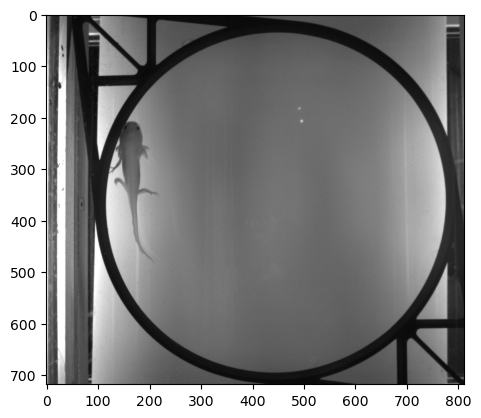

In [92]:
plt.imshow(frame,'gray')
print(frame_ring.shape)

(700, 700, 3)


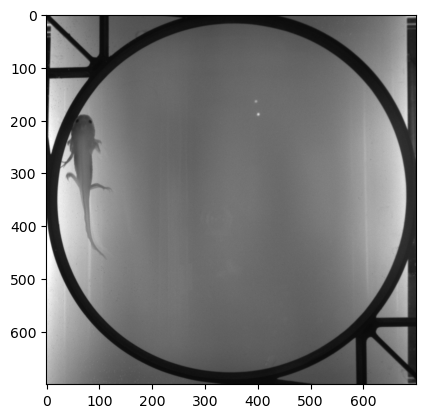

In [93]:
cropped = frame[18:718, 95:795, :]
plt.imshow(cropped,'gray')
print(cropped.shape)

(700, 700, 3)


In [123]:
frame_ring = cropped.copy()
print(frame_ring.shape)

circle_x = int(frame_ring.shape[1]/2)
circle_y = int(frame_ring.shape[0]/2)
circle_radius = np.max([int(frame_ring.shape[0]/2), int(frame_ring.shape[1]/2)])
print([circle_x, circle_radius])

(700, 700, 3)
[350, np.int64(350)]


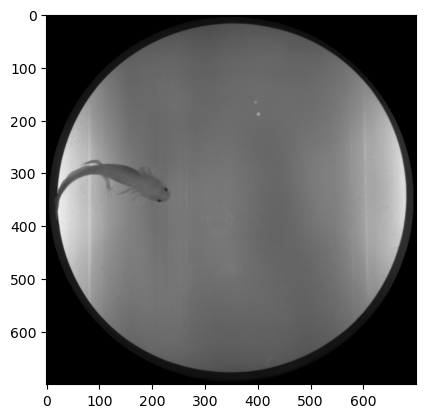

In [125]:
# Apply mask to the area of interest
mask_ring = np.zeros(frame_ring.shape)

#mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
mask_ring = cv2.circle(mask_ring, (circle_x, circle_y), 345, (255,255,255), -1)

frame_ring[mask_ring ==  0] = 0
plt.imshow(frame_ring,'gray')

In [29]:
np.max([int(frame_ring.shape[0]/2), int(frame_ring.shape[1]/2)])

np.int64(406)

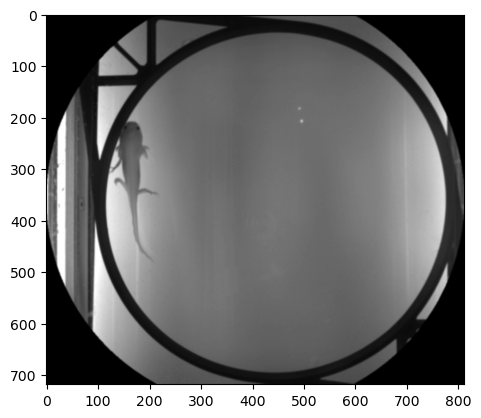

In [32]:
## gaussian blur
gray_ring = cv2.cvtColor(frame_ring, cv2.COLOR_BGR2GRAY)
blur_ring = cv2.GaussianBlur(gray_ring, (5, 5), 0)
plt.imshow(blur_ring,'gray')

Obtained threshold:  67.0


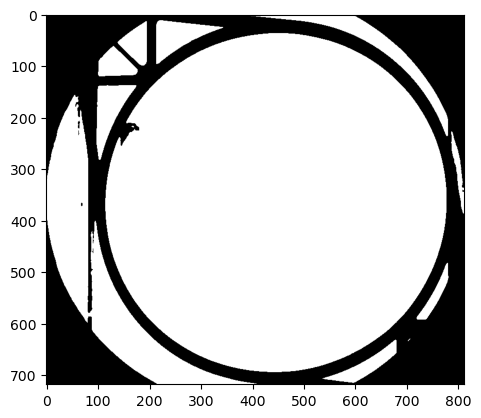

In [35]:
# Applying Otsu's method setting the flag value into cv.THRESH_OTSU.
# Use a bimodal image as an input.
# Optimal threshold value is determined automatically.
otsu_threshold, image_th = cv2.threshold(
    blur_ring, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU,
)
print("Obtained threshold: ", otsu_threshold)
plt.imshow(image_th,'gray')

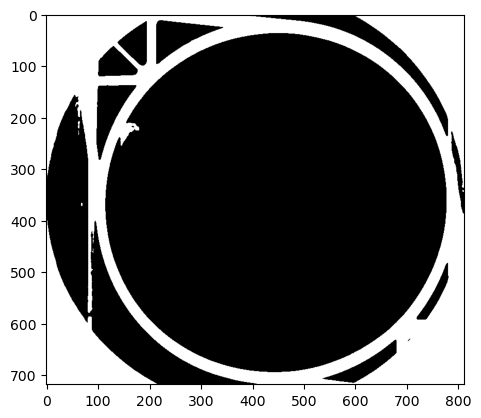

In [67]:
# Copy the thresholded image.
im_floodfill = image_th.copy()
im_floodfill = cv2.bitwise_not(im_floodfill)
plt.imshow(im_floodfill,'gray')

In [68]:
#circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 4, minRadius = 120, maxRadius = 140)
#circles = np.uint8(np.around(circles))

circles = cv2.HoughCircles(im_floodfill, cv2.HOUGH_GRADIENT, dp = 1.5, minDist = 4, 
                           param1=100, param2=50, 
                           minRadius = 100, maxRadius = 500) ## add param1 and param2; reduce the distance 

#circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, dp = 1.5, minDist = 2, param1=100, param2=50, minRadius = 120, maxRadius = 140)
#circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = maxRadius_init)

In [69]:
circles is not None

True

In [70]:
if circles is not None:
    circles = np.round(circles[0, :]).astype("int")

    # Sort by radius, smallest first
    circles = sorted(circles, key=lambda c: c[2])

    # Smallest circle
    circle_run = circles[0]
    circle_x = circle_run[0]
    circle_y = circle_run[1] 
    #circle_radius = circle_run[2]  - 6
    circle_radius = circle_run[2] - 4
        
    circle_position = [circle_x, circle_y, circle_radius]
    
#print(circles)
print(circle_position)

[np.int64(322), np.int64(256), np.int64(161)]


In [ ]:
#frame_0 = frame
mask = np.zeros(frame.shape)
#mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
mask = cv2.circle(mask, (circle_position[0], circle_position[1]), circle_position[2], (255,255,255), -1)
frame[mask ==  0] = 0
plt.imshow(frame,'gray')

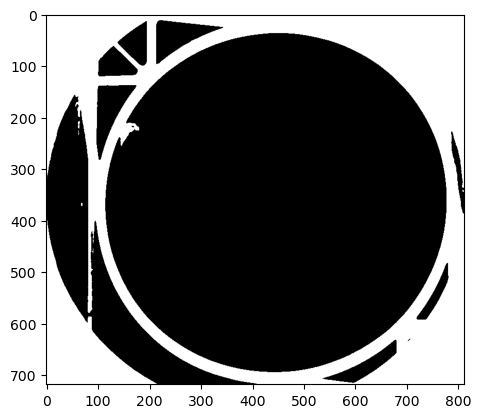

In [43]:
# Mask used to flood filling.
# Notice the size needs to be 2 pixels than the image.
h, w = image_th.shape[:2]
mask_floodfill = np.zeros((h+2, w+2), np.uint8)

# Floodfill from point (0, 0)
cv2.floodFill(im_floodfill, mask_floodfill, (400,0), 255);
#cv2.floodFill(im_floodfill, mask_floodfill, (250,250), 255);
plt.imshow(im_floodfill,'gray')

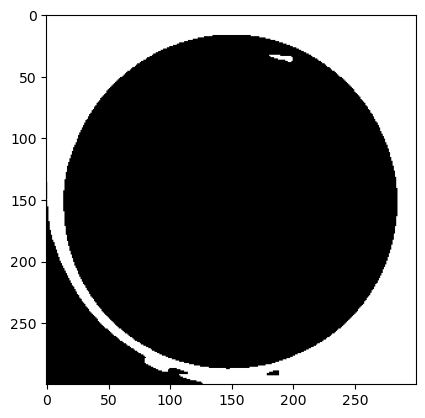

In [47]:
cv2.floodFill(im_floodfill, mask_floodfill, (299, 299), 255);
plt.imshow(im_floodfill,'gray')

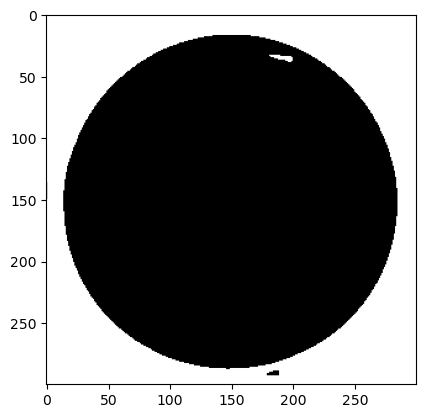

In [48]:
cv2.floodFill(im_floodfill, mask_floodfill, (0, 299), 255);
plt.imshow(im_floodfill,'gray')

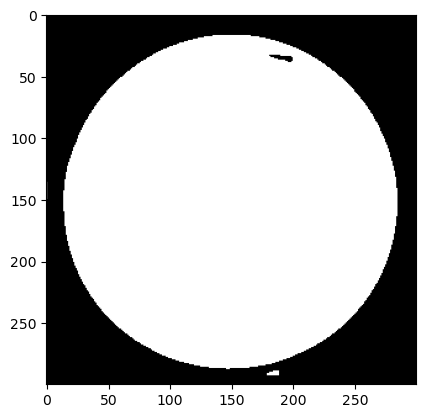

In [49]:
# Invert floodfilled image
im_floodfill_inv = cv2.bitwise_not(im_floodfill)
plt.imshow(im_floodfill_inv,'gray')

In [ ]:
contours, hierarchy = cv2.findContours(
    im_floodfill_inv,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
disk = np.zeros_like(im_floodfill_inv)

if contours:
    biggest_contour = max(contours, key=cv2.contourArea)
    
    (x, y), radius = cv2.minEnclosingCircle(biggest_contour)
    center = (int(x), int(y))
    radius = int(radius)
    print("Center:", center)
    print("Radius:", radius)
    
    # Draw circle for visualization
    
    output = cv2.cvtColor(im_floodfill_inv, cv2.COLOR_GRAY2BGR)
    cv2.circle(output, center, radius, (0, 255, 0), 2)
    cv2.circle(output, center, 2, (0, 0, 255), 3)
    
    cv2.imshow("Minimal enclosing circle", output)
    cv2.waitKey(0)
    
    #cv2.drawContours(disk, [biggest_contour], -1, 255, thickness=cv2.FILLED)
    
#plt.imshow(disk,'gray')


Center: (148, 151)
Radius: 135


In [ ]:
#####################################################################
##
## convert the output formats of SLEAP
##
#####################################################################

In [23]:
import h5py
import cv2
import numpy as np

In [24]:
# name of source video and paths
outdir_sleap = '/Users/jingkui.wang/workspace/imp/image_analysis_test/results/videos_sleap_test/outputs/' # path to SLEAP output

input_file = 'labels_20manual_trained_infer80Frame_manual80Correction_trainedModel_test_v1.v009.000_wildtype_A1.analysis.h5'
codec = 'DIVX' # try other codecs if the default doesn't work ('DIVX', 'avc1', 'XVID') note: this list is non-exhaustive

output_file = 'labels_20manual_trained_infer80Frame_manual80Correction_trainedModel_test_v1.v009.000_wildtype_A1.analysis.mp4'

In [25]:
with h5py.File(outdir_sleap + input_file, "r") as f:
    data = f["images"]
    
    first = data[0]
    first = cv2.normalize(first, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    first = cv2.cvtColor(first, cv2.COLOR_GRAY2BGR)

    h, w = first.shape[:2]

    out = cv2.VideoWriter(
        outdir_sleap + output_file,
        cv2.VideoWriter_fourcc(*"mp4v"),
        30,
        (w, h)
    )

    for i in range(data.shape[0]):
        frame = data[i]
        frame = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
        out.write(frame)

    out.release()

KeyError: "Unable to synchronously open object (object 'images' doesn't exist)"

<Closed HDF5 file>